In [51]:
import pandas as pd
import numpy as np
# 

In [52]:
og_df = pd.read_excel('data_files/merged_excel.xlsx', sheet_name='All Seasons')  
og_df.insert(0, 'Season', og_df.pop('Season'))
df_main = df = og_df.drop(columns=['WS', 'WS/48', 'SRS', 'GB'])
df_main

,Season,Rank,Player,Age,Tm,First,Pts Won,Pts Max,Share,G,...,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Conference Ranking
0,2003-2004,1,Kevin Garnett,27,MIN,120,1219,1230,0.991,82,...,2.2,0.499,0.256,0.791,58.0,24.0,0.707,94.5,89.1,1.0
1,2003-2004,2,Tim Duncan,27,SAS,0,716,1230,0.582,69,...,2.7,0.501,0.167,0.599,57.0,25.0,0.695,91.5,84.3,2.0
2,2003-2004,3,Jermaine O'Neal,25,IND,2,523,1230,0.425,78,...,2.6,0.434,0.111,0.757,61.0,21.0,0.744,91.4,85.6,1.0
3,2003-2004,4,Peja StojakoviÄ‡,26,SAC,1,281,1230,0.228,81,...,0.2,0.480,0.433,0.927,55.0,27.0,0.671,102.8,97.8,4.0
4,2003-2004,5,Kobe Bryant,25,LAL,0,212,1230,0.172,65,...,0.4,0.438,0.327,0.852,56.0,26.0,0.683,98.2,94.3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,2023-2024,5,Jalen Brunson,27,NYK,0,142,990,0.143,77,...,0.2,0.479,0.401,0.847,50.0,32.0,0.610,112.8,108.2,2.0
280,2023-2024,6,Jayson Tatum,25,BOS,0,86,990,0.087,74,...,0.6,0.471,0.376,0.833,64.0,18.0,0.780,120.6,109.2,1.0
281,2023-2024,7,Anthony Edwards,22,MIN,0,18,990,0.018,79,...,0.5,0.461,0.357,0.836,56.0,26.0,0.683,113.0,106.5,3.0
282,2023-2024,8,Domantas Sabonis,27,SAC,0,3,990,0.003,82,...,0.6,0.594,0.379,0.704,46.0,36.0,0.561,116.6,114.8,9.0


In [53]:
df_main.columns

Index(['Season', 'Rank', 'Player', 'Age', 'Tm', 'First', 'Pts Won', 'Pts Max',
       'Share', 'G', 'MP', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'FG%', '3P%',
       'FT%', 'W', 'L', 'W/L%', 'PS/G', 'PA/G', 'Conference Ranking'],
      dtype='object')

Exploratory Data Analysis (EDA)

In [54]:
df_main.sort_values(by=['Share'],ascending=False)

,Season,Rank,Player,Age,Tm,First,Pts Won,Pts Max,Share,G,...,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Conference Ranking
177,2015-2016,1,Stephen Curry,27,GSW,131,1310,1310,1.000,79,...,0.2,0.504,0.454,0.908,73.0,9.0,0.890,114.9,104.1,1.0
132,2012-2013,1,LeBron James,28,MIA,120,1207,1210,0.998,76,...,0.9,0.565,0.406,0.753,66.0,16.0,0.805,102.9,95.0,1.0
0,2003-2004,1,Kevin Garnett,27,MIN,120,1219,1230,0.991,82,...,2.2,0.499,0.256,0.791,58.0,24.0,0.707,94.5,89.1,1.0
148,2013-2014,1,Kevin Durant,25,OKC,119,1232,1250,0.986,81,...,0.7,0.503,0.391,0.873,59.0,23.0,0.720,106.2,99.8,2.0
89,2009-2010,1,LeBron James,25,CLE,116,1205,1230,0.980,76,...,1.0,0.503,0.333,0.767,61.0,21.0,0.744,102.1,95.6,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2009-2010,12T,Chris Bosh,25,TOR,0,1,1230,0.001,70,...,1.0,0.518,0.364,0.797,40.0,42.0,0.488,104.1,105.9,9.0
100,2009-2010,12T,Chauncey Billups,33,DEN,0,1,1230,0.001,73,...,0.1,0.418,0.386,0.910,53.0,29.0,0.646,106.5,102.4,4.0
221,2018-2019,11T,Rudy Gobert,26,UTA,0,1,1010,0.001,81,...,2.3,0.669,NaN,0.636,50.0,32.0,0.610,111.7,106.5,5.0
88,2008-2009,12,Yao Ming,28,HOU,0,1,1210,0.001,77,...,1.9,0.548,1.000,0.866,53.0,29.0,0.646,98.4,94.4,5.0


In [55]:
# The features I intend to use are Age, PTS, TRB, AST, STL, BLK, FG%, 3P%, FT%, W/L%', PS/G, PA/G, conference ranking. Target is Share
# Identifyin na values in each column
df_main.isnull().sum()
df_main[df_main['L'].isna()]

,Season,Rank,Player,Age,Tm,First,Pts Won,Pts Max,Share,G,...,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Conference Ranking
28,2004-2005,13,Vince Carter,28,TOT,0,3,1270,0.002,77,...,0.6,0.452,0.406,0.798,NaN,NaN,NaN,NaN,NaN,NaN
82,2008-2009,6,Chauncey Billups,32,TOT,0,33,1210,0.027,79,...,0.2,0.418,0.408,0.913,NaN,NaN,NaN,NaN,NaN,NaN
102,2009-2010,12T,Stephen Jackson,31,TOT,0,1,1230,0.001,81,...,0.5,0.423,0.328,0.779,NaN,NaN,NaN,NaN,NaN,NaN
243,2020-2021,9,Derrick Rose,32,TOT,1,10,1010,0.010,50,...,0.4,0.470,0.388,0.866,NaN,NaN,NaN,NaN,NaN,NaN
247,2020-2021,13T,James Harden,31,TOT,0,1,1010,0.001,44,...,0.8,0.466,0.362,0.861,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# Since all of them have extremely low vote shares, they're not statistically significant for training a regression model. I have decided to drop them from the df.
df_main = df_main[df_main['Tm'] != 'TOT']
df_main.isnull().sum()

Season                0
Rank                  0
Player                0
Age                   0
Tm                    0
First                 0
Pts Won               0
Pts Max               0
Share                 0
G                     0
MP                    0
PTS                   0
TRB                   0
AST                   0
STL                   0
BLK                   0
FG%                   0
3P%                   6
FT%                   0
W                     0
L                     0
W/L%                  0
PS/G                  0
PA/G                  0
Conference Ranking    0
dtype: int64

Only na values for 3P% as they have never attempted a 3 pointer that season


In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

<AxesSubplot:xlabel='Share', ylabel='Count'>

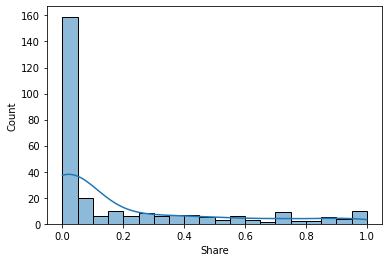

In [58]:
sns.histplot(df_main['Share'], bins=20, kde=True)

<AxesSubplot:>

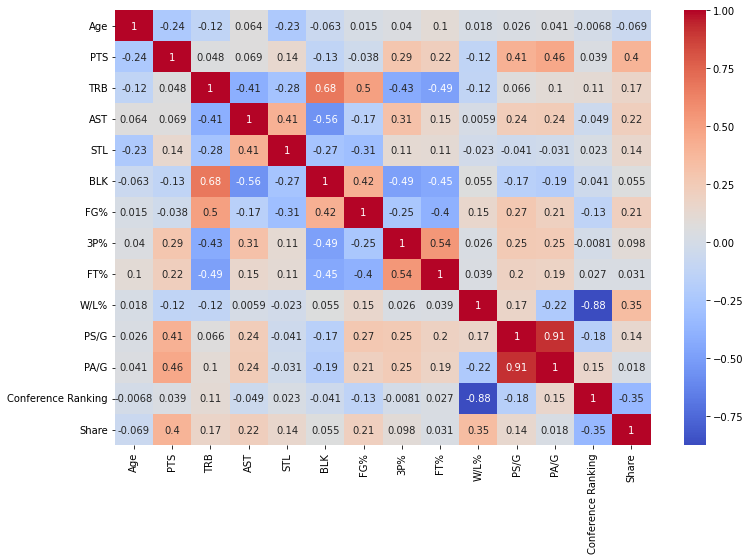

In [59]:
# Correlation matrix
features = ['Age', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'FG%', '3P%', 'FT%', 'W/L%', 'PS/G', 'PA/G', 'Conference Ranking', 'Share']
corr = df[features].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

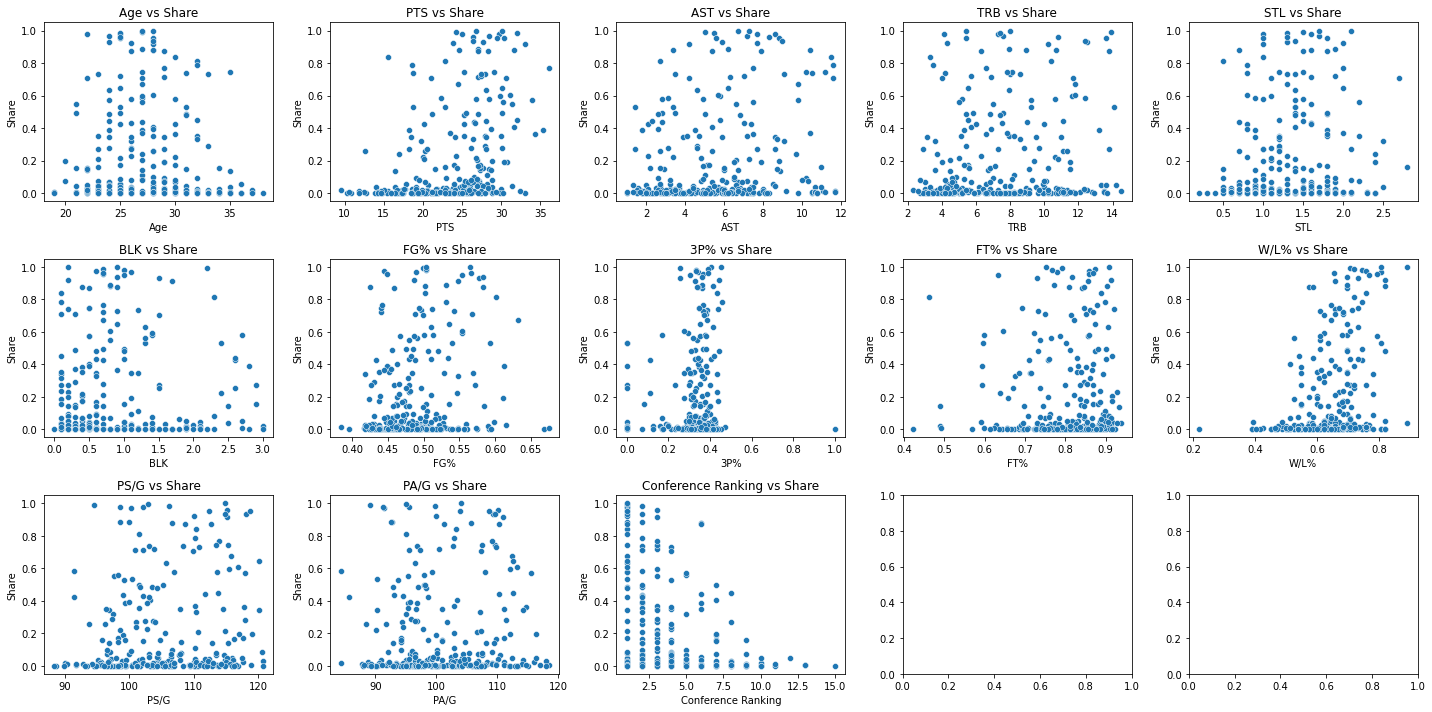

In [60]:
# Feature vs Target Visuals

features = ['Age', 'PTS', 'AST', 'TRB', 'STL','BLK', 'FG%', '3P%','FT%', 'W/L%', 'PS/G', 'PA/G', 'Conference Ranking']
target = 'Share'
rows = 3
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 10))
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.scatterplot(data=df, x=feature, y=target, ax=axes[i])
    axes[i].set_title(f'{feature} vs {target}')

plt.tight_layout()

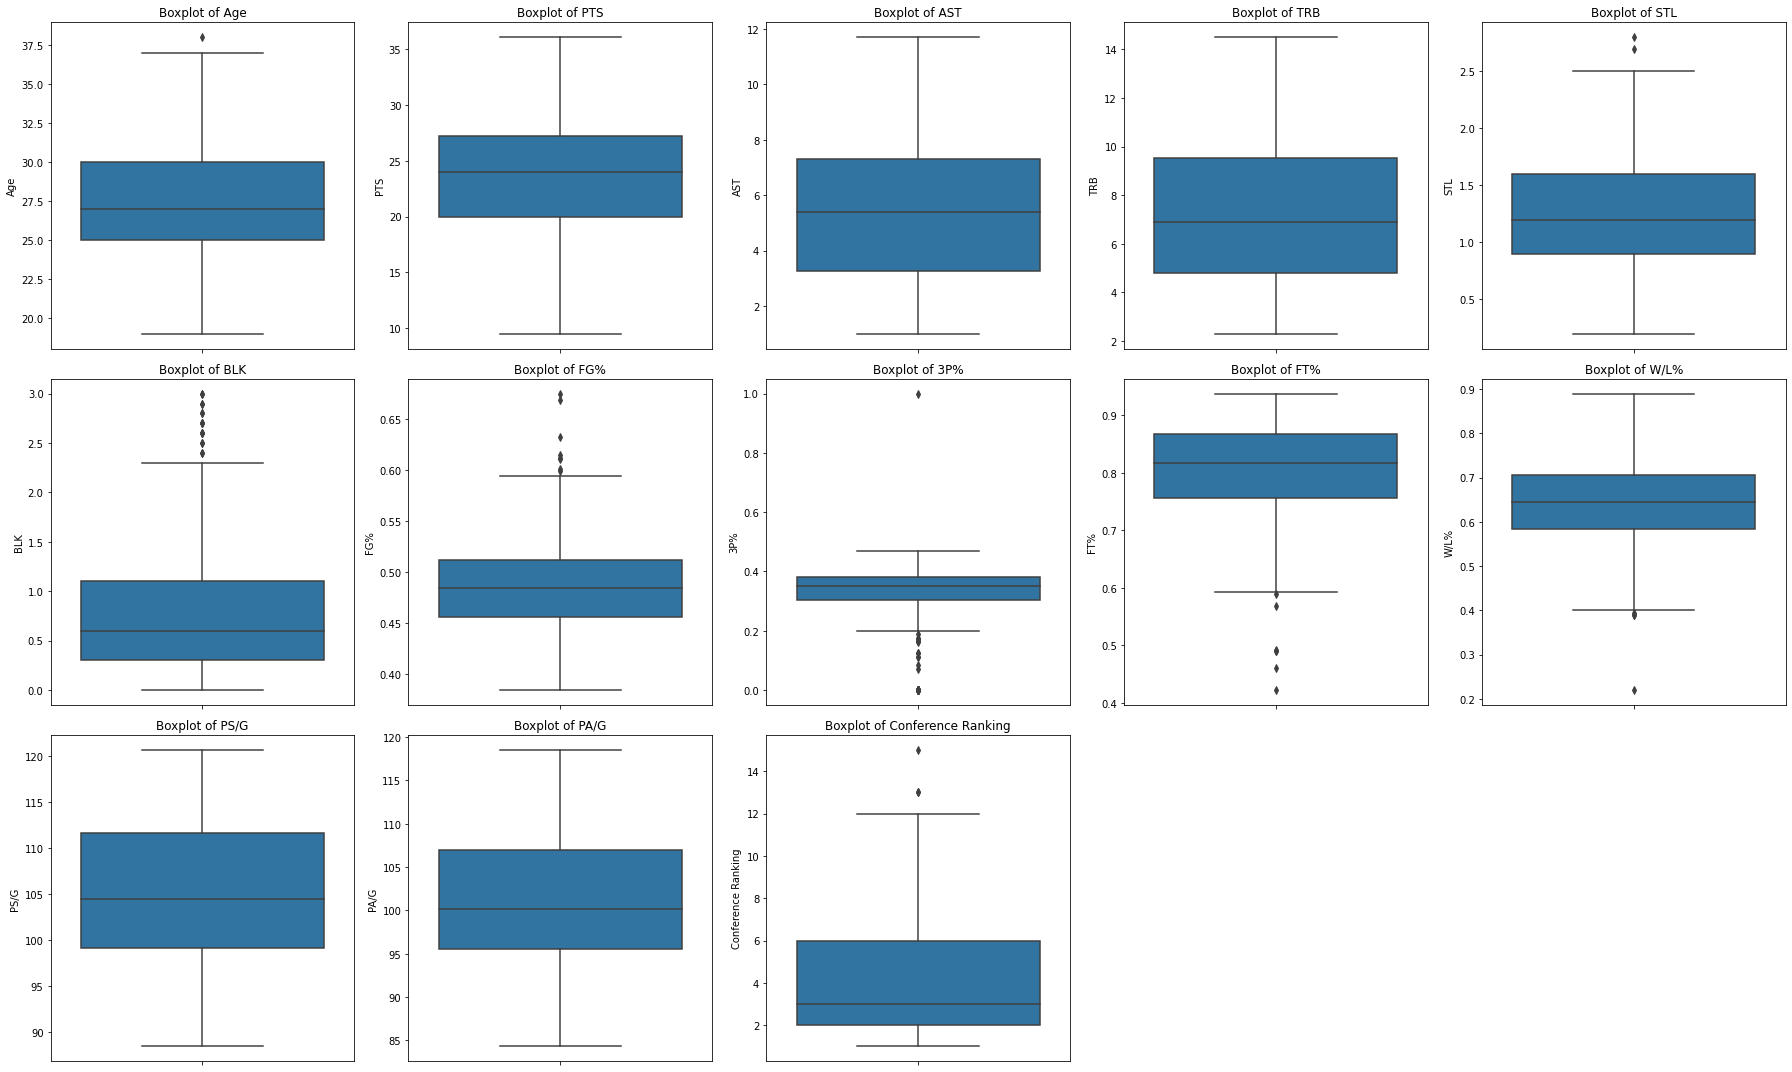

In [61]:
# Boxplot for outliers

fig, axes = plt.subplots(3, 5, figsize=(25, 15))  
axes = axes.flatten()

# Plot each boxplot
for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')

for j in range(len(features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [62]:
# Found an anomaly for 3P%
df_main.sort_values(by=["3P%"], ascending=False)

,Season,Rank,Player,Age,Tm,First,Pts Won,Pts Max,Share,G,...,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Conference Ranking
88,2008-2009,12,Yao Ming,28,HOU,0,1,1210,0.001,77,...,1.9,0.548,1.000,0.866,53.0,29.0,0.646,98.4,94.4,5.0
68,2007-2008,9,Steve Nash,33,PHO,0,18,1260,0.014,81,...,0.1,0.504,0.470,0.906,55.0,27.0,0.671,110.1,105.0,4.0
44,2006-2007,2,Steve Nash,32,PHO,44,1013,1290,0.785,76,...,0.1,0.532,0.455,0.899,61.0,21.0,0.744,110.2,102.9,2.0
177,2015-2016,1,Stephen Curry,27,GSW,131,1310,1310,1.000,79,...,0.2,0.504,0.454,0.908,73.0,9.0,0.890,114.9,104.1,1.0
142,2012-2013,11,Stephen Curry,24,GSW,0,3,1210,0.002,78,...,0.2,0.451,0.453,0.900,47.0,35.0,0.573,101.2,100.3,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17,2004-2005,2,Shaquille O'Neal,32,MIA,58,1032,1270,0.813,73,...,2.3,0.601,NaN,0.461,59.0,23.0,0.720,101.5,95.0,1.0
29,2004-2005,14T,P.J. Brown,35,NOH,0,1,1270,0.001,82,...,0.6,0.446,NaN,0.864,18.0,64.0,0.220,88.4,95.5,15.0
51,2006-2007,9T,Carlos Boozer,25,UTA,0,7,1290,0.005,74,...,0.3,0.561,NaN,0.685,51.0,31.0,0.622,101.5,98.6,5.0
54,2006-2007,12T,Shaquille O'Neal,34,MIA,0,3,1290,0.002,40,...,1.4,0.591,NaN,0.422,44.0,38.0,0.537,94.6,95.5,5.0


 Yao Ming has 100% 3 pointer percentage for 2008-09 season as he only attempted 1 and made 1, but I am still keeping this stat as I am not overemphasising on 3s.


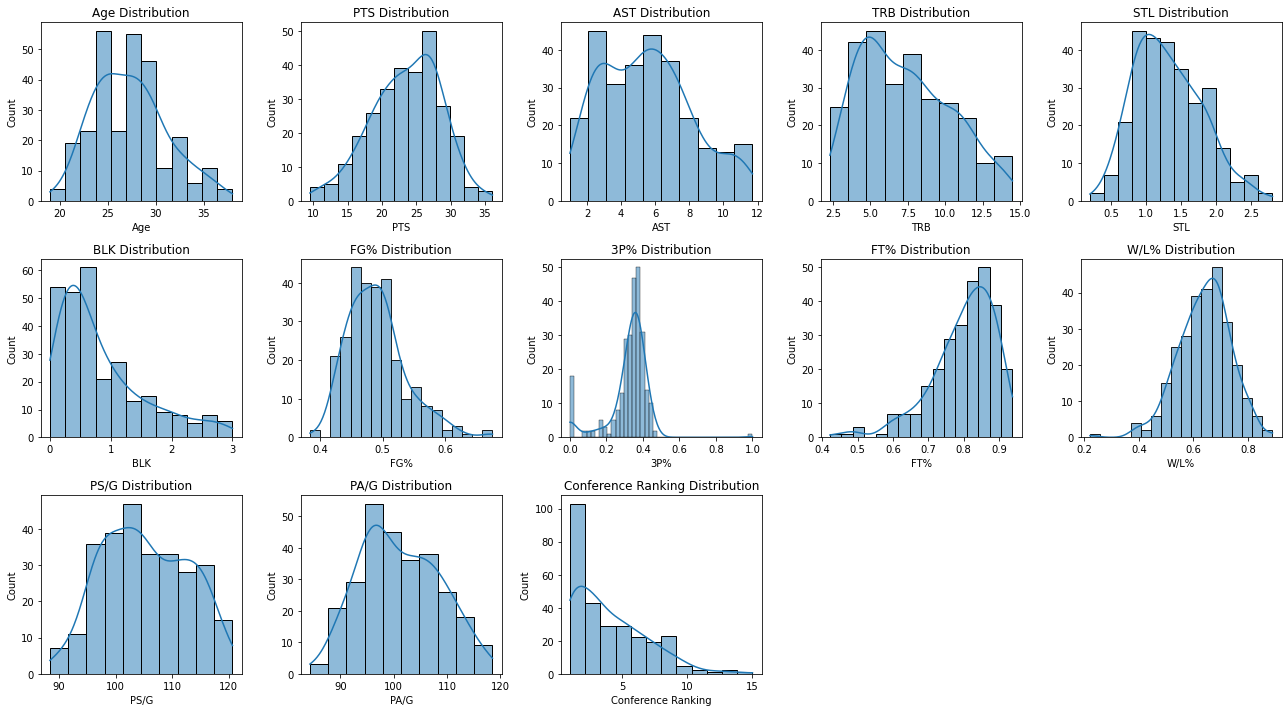

In [63]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df_main[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')

# Hide any empty subplots if len(cols) < n_rows * n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [64]:
# Convert NA to 0.0 for 3P%

df_main['3P%'] = df_main['3P%'].fillna(0.0)


C:\Users\User\AppData\Local\Temp\ipykernel_20336\3912824704.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_main['3P%'] = df_main['3P%'].fillna(0.0)


In [65]:
df_main.columns

Index(['Season', 'Rank', 'Player', 'Age', 'Tm', 'First', 'Pts Won', 'Pts Max',
       'Share', 'G', 'MP', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'FG%', '3P%',
       'FT%', 'W', 'L', 'W/L%', 'PS/G', 'PA/G', 'Conference Ranking'],
      dtype='object')

In [67]:
df_main.to_pickle('data_files/df_main.pkl')